In [1]:
import mfem.ser as mfem
import numpy as np
import math

import time


In [2]:
%matplotlib inline
import matplotlib.pylab as plt
from IPython.display import display, clear_output
import time
def animate(delay=0.01):
    fig = plt.gcf()
    time.sleep(delay)       # Sleep for a moment to slow down the animation
    clear_output(wait=True) # Clear output for dynamic display
    display(fig)            # Reset display
                # Prevent overlapping and layered plots

In [ ]:
start = time.perf_counter()

#initialize variables
mesh_file = "../Inputs/Mesh_3x90x3_T01.mesh"

dsF_file = "../Inputs/dsF_3x90x3_T01.txt" 
	
AMR = 2
      
order = 1

visualization = True
	
zeta = 1.0 * 0.375 # dynamically scale zeta for smallest size
dh = 0.2e-4
eps = 1.0e-6				
dt = 1.864558472553700e-01 /40
tm = 0.0
	
t_minus = 7.619047619047619e-01
D0 = 0.00489
Frd = 96485.3365
Cst1 = 1.6021766e-19/(1.3806488e-23*300.0)
alp = 0.5;						
			
rho = 0.0501;		 	
Cr = 3.0; 					
Vsr = 0.2;			
Vcut = 2.7;				
			
ReMsh = False; 	

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")

Elapsed time: 0.000270 seconds


In [4]:
start = time.perf_counter()


#!pip install mfem
mesh = mfem.Mesh(mesh_file)

mesh.EnsureNCMesh(True)

fec = mfem.H1_FECollection(order, mesh.Dimension())

fespace = mfem.FiniteElementSpace(mesh, fec)

print(f"Number of unknowns: {fespace.GetTrueVSize()}")

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")

Number of unknowns: 1456
Elapsed time: 0.005715 seconds


In [5]:
start = time.perf_counter()


# 4. read in distance function to define geometry
# It has the size as the grid function


dsF = mfem.GridFunction(fespace)  

Onm = dsF.Size(); 

	
with open(dsF_file, 'r') as myfile:
    lines = myfile.readlines()
    for i in range(Onm):
        dsF[i] = float(lines[i])


    
nC = 2 ** mesh.Dimension()
VertVal = mfem.doubleArray(nC)
vSum = 0


# levels of refinement


if AMR > 0:
    ReMsh = True

    print("Adaptive Mesh Refinement is on ...")

	# create an array to store vertex labels of each element
    Ds2Br = 0.0;		# distance of an element to the internal boundary	
		
    Lv = AMR; 
    LvFc = mfem.doubleArray(Lv)

    for i in range(Lv):
        LvFc[i] = 3 * 2 ** (-i)
		
    
	
	# create an array to store the labels of elements needed to be refined.

    refinement_list = mfem.intArray()

    for Lv in range(AMR):
            
        for e in range(mesh.GetNE()):
            # get the distance values at the 4 vertices
            dsF.GetNodalValues(e,VertVal) 
            

            
			# distance from element center to the internal boundary
            vSum = 0.0

            for vt in range(nC):
                vSum += VertVal[vt]

            Ds2Br = vSum/nC

		
			# collect the element labels 
            if abs(Ds2Br) < LvFc[Lv]*dh:
                refinement_list.Append(e)

		# mesh refinement
        mesh.GeneralRefinement(refinement_list)
	
		# update relevant objects 
        fespace.Update()
        dsF.Update() 
		
        # clear refinement list
        refinement_list.DeleteAll() 

	
        
print(f"{Onm} -- {dsF.Size()}")
	
# output mesh and vertex coordinates following the order of GridFucntion
mesh.Save("Mesh_AMR_3x90x3_T01_py.mesh")

CrDt = mfem.GridFunction(fespace)
mesh.GetVertices(CrDt)
CrDt.Save("N_Crd_3x90x3_T01_py.gf")

Rmin, Rmax = mfem.Vector(), mfem.Vector()
Rmin, Rmax = mesh.GetBoundingBox()
#Rmax.Print()
dsF.Save("dsF_3x90x3_T01_py.gf")

            
elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")
	
		

Adaptive Mesh Refinement is on ...
1456 -- 3917
Elapsed time: 0.060275 seconds


In [6]:
# // 	=====================================================================
# 	// 	//   _____                        _                               
# 	// 	//  |  __ \                      (_)                              
# 	// 	//  | |  | | ___  _ __ ___   __ _ _ _ __    _ __   __ _ _ __ __ _ 
# 	// 	//  | |  | |/ _ \| '_ ` _ \ / _` | | '_ \  | '_ \ / _` | '__/ _` |
# 	// 	//  | |__| | (_) | | | | | | (_| | | | | | | |_) | (_| | | | (_| |
# 	// 	//  |_____/ \___/|_| |_| |_|\__,_|_|_| |_| | .__/ \__,_|_|  \__,_|
# 	// 	//                                         | |                    
# 	// 	//                                         |_|                    
# 	// 	=====================================================================
	
start = time.perf_counter()


# number of vertices
nV = dsF.Size()
	
# coordinates of vertices
#xp, yp, zp, vert3d = mfem.Vector(nV), mfem.Vector(nV), mfem.Vector(nV), mfem.Vector(3*nV)

#mesh.GetVertices(vert3d)

# for i in range(nV):
# 	xp[i] = vert3d[i]
# 	yp[i] = vert3d[i+nV]
	#zp[i] = vert3d[i+2*nV]


#number of elements
nE = mesh.GetNE()
print("mesh element", mesh.GetElementSize(0))	

# element volume
EVol = mfem.Vector(nE)

for e in range(nE):
	EVol[e] = mesh.GetElementVolume(e)

# fixed e to i



# 4. Domain parament
psi = mfem.GridFunction(fespace)
AvP = mfem.GridFunction(fespace)
pse = mfem.GridFunction(fespace)


# interpolate domain parameter from distance function
for i in range(nV):
	psi[i] = 0.5 * (1.0 + np.tanh(dsF[i] / (zeta * dh)))
	AvP[i] = -((np.tanh(dsF[i] / (zeta * dh)) ** 2 - 1.0) / (2 * zeta * dh))
	pse[i] = 1.0 - psi[i]

psi += eps
pse += eps

# print("average psi", psi.Sum()/nV)
	
AvB = mfem.GridFunction(fespace)
	
# AvB = AvP
AvB.Assign(AvP)
	
# remove small values of AvP
for i in range(nV):
	if AvP[i] * dh < 1e-4:
		AvP[i] =  0.0
	if AvB[i]*dh < 1e-6:
		AvB[i] = 0.0
    
	
# element average
EAvg = mfem.Vector(nE)
tlPsi = 0.0
for e in range(nE):
	psi.GetNodalValues(e, VertVal)
	vSum = 0.0
	for vt in range(nC):
		vSum += VertVal[vt]

	EAvg[e] = vSum/nC
	tlPsi += EAvg[e] * EVol[e]

# print("tlPsi", tlPsi)
# print("nC", nC)
# print("vSum", vSum)

tlPse = 0.0
for e in range(nE):
	pse.GetNodalValues(e, VertVal)
	vSum = 0.0
	for vt in range(nC):
		vSum += VertVal[vt]
	EAvg[e] = vSum/nC
	tlPse += EAvg[e] * EVol[e]

# print("tlPse", tlPse)


tlAvP = 0.0
for e in range(nE):
	AvP.GetNodalValues(e, VertVal)
	vSum = 0.0
	for vt in range(nC):
		vSum += VertVal[vt]
	EAvg[e] = vSum/nC
	tlAvP += EAvg[e] * EVol[e]

# print("tlAvP", tlAvP)
	
psi.Save("psi_3x90x3_T01_py.gf")
AvP.Save("AvP_3x90x3_T01_py.gf")
	
#target current
trgI = tlPsi*rho*(0.9-0.3)/(3600.0/Cr)

# print("trgI", trgI) 
	
sCrnt = 0.0

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")


mesh element 2.0000000000000015e-05
Elapsed time: 0.131240 seconds


In [7]:
# // // 	=============================
# 	// // 	   _____       _____  
# 	// // 	  / ____|     |  __ \ 	//
# 	// // 	 | |     _ __ | |__) |
# 	// // 	 | |    | '_ \|  ___/ 
# 	// // 	 | |____| | | | |     
# 	// // 	  \_____|_| |_|_|     
# 	// // 	==============================

start = time.perf_counter()


# initial condition
CnP = mfem.GridFunction(fespace)
Cp0 = 0.3
CnP.Assign(Cp0)
# print("Cnp Min:", CnP.Min(), "Cnp Max:",CnP.Max())
	
# degree of lithiation
Xfr = 0.0

TmpF = mfem.GridFunction(fespace)

TmpF.Assign(CnP)
TmpF *= psi
xSum = 0.0
for e in range(nE):

	TmpF.GetNodalValues(e,VertVal) 
	vSum = 0.0
	for vt in range(nC):
		vSum += VertVal[vt]
		
	EAvg[e] = vSum/nC;		 		  
	xSum += EAvg[e]*EVol[e]

Xfr = xSum/tlPsi

# print("initial Xfr:", Xfr)
# print("xSum:", xSum)
# print("tlPsi in CnP:", tlPsi)
	
	
# 5. create K and M matrices
boundary_dofs = mfem.intArray()
Kmatp, Mmatp, Tmatp, Rmat = mfem.SparseMatrix(), mfem.SparseMatrix(), mfem.SparseMatrix(), mfem.SparseMatrix()	


# SBM mass matrix
Mt = mfem.BilinearForm(fespace)
cPs = mfem.GridFunctionCoefficient(psi)
Mt.AddDomainIntegrator(mfem.MassIntegrator(cPs))
Mt.Assemble()
Mt.FormSystemMatrix(boundary_dofs,Mmatp)
	
			
M_solver = mfem.CGSolver()
M_prec = mfem.DSmoother()

M_solver.iterative_mode = False
M_solver.SetRelTol(1e-7)
M_solver.SetAbsTol(0)
M_solver.SetMaxIter(200)
M_solver.SetPrintLevel(0)
M_solver.SetPreconditioner(M_prec)
M_solver.SetOperator(Mmatp)


# for stiffness matrix
Dp = mfem.GridFunction(fespace)
one = mfem.ConstantCoefficient(1.0)
Tt = mfem.BilinearForm(fespace)
Tt.AddDomainIntegrator(mfem.DiffusionIntegrator(one))
Tt.Assemble()
Tt.FormSystemMatrix(boundary_dofs, Tmatp)	
	

	
Rmat = Tmatp
K2 = mfem.BilinearForm(fespace)
	
	
# force term
RCp = mfem.GridFunction(fespace)
Rxn = mfem.GridFunction(fespace)

Rxn.Assign(0.0)
# Rxn.Assign(1e-7)
	
# // // 	double Rv = trgI/tlAvP;
# // // 	Rxn = AvP;
# // // 	Rxn *= Rv;
	
	
# RHS vector
B2 = mfem.LinearForm()
Ft = mfem.GridFunction(fespace)
Fb = mfem.Vector()
		

# create a Vector for CnP
CpV0 = mfem.Vector()
CnP.GetTrueDofs(CpV0)

	
nDof = CpV0.Size();	

CpVn, RHSp = mfem.Vector(nDof), mfem.Vector(nDof)
# print("CpVn Size:", CpVn.Size())

# print("CpV0 Min and Max",CpV0.Min(), CpV0.Max())
# print("CpVn Min and Max",CpVn.Min(), CpVn.Max())
# print("RHSP Min and Max",RHSp.Min(), RHSp.Max())


PsVc = mfem.Vector()
psi.GetTrueDofs(PsVc)
	
# vector for recovering GridFunction
bt = mfem.LinearForm(fespace)
bt.Assemble()

# CnP.Save("CnP_py")


elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")



Elapsed time: 0.211929 seconds


In [8]:

	# // 	// ========================
	# // 	//    _____       ______ 
	# // 	//   / ____|     |  ____|
	# // 	//  | |     _ __ | |__   
	# // 	//  | |    | '_ \|  __|  
	# // 	//  | |____| | | | |____ 
	# // 	//   \_____|_| |_|______|
	# // 	// ========================

start = time.perf_counter()


CnE = mfem.GridFunction(fespace)
De = mfem.GridFunction(fespace)
CeT = mfem.GridFunction(fespace)
	
Ce0 = 0.001
CnE.Assign(Ce0)
cPe = mfem.GridFunctionCoefficient(pse)

# 5. create K and M matrices
Kmate, Mmate, TmatL, TmatR = mfem.SparseMatrix(), mfem.SparseMatrix(), mfem.SparseMatrix(), mfem.SparseMatrix()
	

# SBM mass matrix
Me = mfem.BilinearForm(fespace)
Me.AddDomainIntegrator(mfem.MassIntegrator(cPe))
Me.Assemble()
Me.FormSystemMatrix(boundary_dofs, Mmate)


# print("||Mmate||_max ~", Mmate.MaxNorm())


# print("Mmate before", Mmate.PrintInfo())
# print("Mmate Before: ")
# Mmate.PrintInfo()


Kmate = Mmate
TmatL = Mmate
TmatR = Mmate
# TmatR = mfem.SparseMatrix(Mmate)

# print("TmatR sparse")
# print("TmatR", TmatR.PrintInfo())
# print("TmatR: ")
# TmatR.PrintInfo()


# print("Mmate", Mmate.PrintInfo())
# print("Kmate", Kmate.PrintInfo())
# print("TmatL", TmatL.PrintInfo())
# print("TmatR", TmatR.PrintInfo())



Rxe = mfem.GridFunction(fespace)
CeV0 = mfem.Vector()
CnE.GetTrueDofs(CeV0)
CeVn, RHSe = mfem.Vector(nDof), mfem.Vector(nDof)
CeVn *= 0.0

PeR = mfem.GridFunction(fespace)
# PeR = pse # this is the main issue
PeR.Assign(pse)
PeR *= -1.0
matCoef_R = mfem.GridFunctionCoefficient(PeR)
eCrnt = 0.0
L_w = (Rmax[1] - Rmin[1])*(Rmax[2] - Rmin[2])

# print("L_w", L_w)


# Neumann BCs. Here imposing on west boundary.
nbc_w_bdr = mfem.intArray(mesh.bdr_attributes.Max())

nbc_w_bdr.Assign(0)
nbc_w_bdr[0] = 1

# print("CeV0 Min and Max",CeV0.Min(), CeV0.Max())
# print("CeVn Min and Max",CeVn.Min(), CeVn.Max())

Me_solver = mfem.CGSolver()
Me_prec = mfem.DSmoother()

Me_solver.iterative_mode = False
Me_solver.SetRelTol(1e-7)
Me_solver.SetAbsTol(0)
Me_solver.SetMaxIter(200)
Me_solver.SetPrintLevel(0)
Me_solver.SetPreconditioner(Me_prec)
Me_solver.SetOperator(TmatL)

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")

Elapsed time: 0.038291 seconds


In [9]:
# // 	========================================
# 	// 	//               _     _____  
# 	// 	//              | |   |  __ \ 		//
# 	// 	//   _ __   ___ | |_  | |__) |
# 	// 	//  | '_ \ / _ \| __| |  ___/ 
# 	// 	//  | |_) | (_) | |_  | |     
# 	// 	//  | .__/ \___/ \__| |_|     
# 	// 	//  | |                       
# 	// 	//  |_|                       
# 	// 	========================================

start = time.perf_counter()


phP = mfem.GridFunction(fespace) # electropotential in particle
kap = mfem.GridFunction(fespace) # conductivity in particle
RpP = mfem.GridFunction(fespace) # reaction 

BvP = 2.9395
phP.Assign(BvP)

KmP = mfem.SparseMatrix()
K4 = mfem.BilinearForm(fespace)

dbc_e_bdr = mfem.intArray(mesh.bdr_attributes.Max())
dbc_e_bdr.Assign(0)
dbc_e_bdr[2] = 1	


	
#// use dbc_e_bdr array to extract all node labels of Dirichlet BC
ess_tdof_list_e = mfem.intArray(0)
fespace.GetEssentialTrueDofs(dbc_e_bdr, ess_tdof_list_e)

B1 = mfem.LinearForm(fespace)
pP0 = mfem.GridFunction(fespace)
B, X, X0 = mfem.Vector(), mfem.Vector(), mfem.Vector()


elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")

Elapsed time: 0.000912 seconds


In [10]:
	
	# // 	========================================
	# // 	// 	              _     ______ 
	# // 	// 	             | |   |  ____|
	# // 	// 	  _ __   ___ | |_  | |__   
	# // 	// 	 | '_ \ / _ \| __| |  __|  
	# // 	// 	 | |_) | (_) | |_  | |____ 
	# // 	// 	 | .__/ \___/ \__| |______|
	# // 	// 	 | |                       
	# // 	// 	 |_|                       
	# // 	========================================

start = time.perf_counter()

	
tc1 = (2*t_minus-1.0)/(2*t_minus*(1.0-t_minus))
tc2 = 1.0/(2*t_minus*(1.0-t_minus))*Cst1

phE = mfem.GridFunction(fespace)
Dmp = mfem.GridFunction(fespace)
kpl = mfem.GridFunction(fespace)
RpE = mfem.GridFunction(fespace)

BvE = -1.0
phE.Assign(BvE)



KmE, Lmat, Rme = mfem.SparseMatrix(), mfem.SparseMatrix(), mfem.SparseMatrix()
Ke1, Ke2 = mfem.BilinearForm(fespace), mfem.BilinearForm(fespace)

dbc_w_bdr = mfem.intArray(mesh.bdr_attributes.Max())
dbc_w_bdr.Assign(0)
dbc_w_bdr[0] = 1

print("|bdr attrs| =", mesh.bdr_attributes.Size())
print("dbc_w_bdr flags:", [int(dbc_w_bdr[i]) for i in range(mesh.bdr_attributes.Max())])

ess_tdof_list_w = mfem.intArray(0)
fespace.GetEssentialTrueDofs(dbc_w_bdr, ess_tdof_list_w)
print("|Dirichlet true DOFs (phE)| =", ess_tdof_list_w.Size())
	
	
#// use dbc_w_bdr array to extract all node labels of Dirichlet BC
ess_tdof_list_w = mfem.intArray(0)
fespace.GetEssentialTrueDofs(dbc_w_bdr, ess_tdof_list_w)

Be1 = mfem.LinearForm(fespace)
Xe, RHE, Re1, Xe0, Fbe = mfem.Vector(), mfem.Vector(), mfem.Vector(), mfem.Vector(), mfem.Vector()
pE0 = mfem.GridFunction(fespace)


	
#	// rate constants
dPHE = mfem.GridFunction(fespace)
Kfw = mfem.GridFunction(fespace)
Kbw = mfem.GridFunction(fespace)
OCV = mfem.GridFunction(fespace)
i0C = mfem.GridFunction(fespace)
	

OCV.Assign(0.0)
i0C.Assign(0.0)
Kfw.Assign(0.0)
Kbw.Assign(0.0)


Vcell = BvP - BvE
val = 0.0

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")

|bdr attrs| = 6
dbc_w_bdr flags: [1, 0, 0, 0, 0, 0]
|Dirichlet true DOFs (phE)| = 16
Elapsed time: 0.001128 seconds


In [11]:
# // 	===================================================================
# 	// 	//   _   _                      _                   _             
# 	// 	//  | | (_)                    | |                 (_)            
# 	// 	//  | |_ _ _ __ ___   ___   ___| |_ ___ _ __  _ __  _ _ __   __ _ 
# 	// 	//  | __| | '_ ` _ \ / _ \ / __| __/ _ \ '_ \| '_ \| | '_ \ / _` |
# 	// 	//  | |_| | | | | | |  __/ \__ \ ||  __/ |_) | |_) | | | | | (_| |
# 	// 	//   \__|_|_| |_| |_|\___| |___/\__\___| .__/| .__/|_|_| |_|\__, |
# 	// 	//                                     | |   | |             __/ |
# 	// 	//                                     |_|   |_|            |___/ 
# 	//  ===================================================================                                   	
	
cnt = 0
t = 0
	
start = time.perf_counter()

	
errP = 1.0
errE = 1.0
inlp = 0


	
#// time stepping

for t in range(8):
	# CnP in particle
	# reaction term for insertion
    # print(t)
    start1 = time.perf_counter()

    startA = time.perf_counter()

    RCp.Assign(Rxn)
    RCp /= rho;	
    cAp = mfem.GridFunctionCoefficient(RCp)
    B2 = mfem.LinearForm(fespace)
    B2.AddDomainIntegrator(mfem.DomainLFIntegrator(cAp))
    B2.Assemble()		
    Ft.Assign(B2)

    # force vector for particle
    Ft.GetTrueDofs(Fb) 
    Fb *= dt

    elapsedA = time.perf_counter() - startA
    print(f"Elapsed time A: {elapsedA:.6f} seconds")

    startB = time.perf_counter()

    #// diffusivity in particle
    for i in range(nV):
        Dp[i] = psi[i] * (0.0277-0.084*CnP[i] + 0.1003*CnP[i]*CnP[i])*1.0e-8
        if Dp[i] > 4.6e-10:
            Dp[i] = 4.6e-10

    cDp = mfem.GridFunctionCoefficient(Dp)
    K2 = mfem.BilinearForm(fespace)
    K2.AddDomainIntegrator(mfem.DiffusionIntegrator(cDp))
    K2.Assemble()
    K2.FormSystemMatrix(boundary_dofs, Rmat)
    Kmatp = Rmat

    elapsedB = time.perf_counter() - startB
    print(f"Elapsed time B: {elapsedB:.6f} seconds")

    startC = time.perf_counter()

    # Euler matrix
    # Tmatp = Mmatp
    # Tmatp.Add(-dt,Kmatp)
    Tmatp = mfem.Add(1.0, Mmatp, -dt, Kmatp)
					
    # vector to store CnP				
    CnP.GetTrueDofs(CpV0)
    # print("CpVo Min:",CpV0.Min(),"CpV0 Max:",CpV0.Max())
    #print(RHSp.Min(), RHSp.Max(),CpVn.Min(), CpVn.Max())

    #// updating particle concentration using Euler	
    Tmatp.Mult(CpV0,RHSp)
    RHSp += Fb
    # print("RHSp.Size() =", RHSp.Size())
    # print("CpVn.Size() =", CpVn.Size())
    # print("RHSp.Min(), RHSp.Max() =", RHSp.Min(), RHSp.Max())
    M_solver.Mult(RHSp,CpVn) 

    # print("Max CpVn after Mult: ", CpVn.Max())

    elapsedC = time.perf_counter() - startC
    print(f"Elapsed time C: {elapsedC:.6f} seconds")

    startD = time.perf_counter()

    t0 = time.perf_counter()
	
			
	# // update only the solid region
    for p in range(nDof):
        if PsVc[p] < 1.0e-5:
            CpVn[p] = Cp0
    t1 = time.perf_counter()

    # recover GridFunction from Vector
    if (ReMsh):
        Mt.RecoverFEMSolution(CpVn, bt, CnP)					 		
    else:
        for p in range(nDof):	
            CnP[p] = CpVn[p];
    t2 = time.perf_counter()


    # print("CnP Max:", CnP.Max())	
    # 
    # for p in range(nDof):	
    #     CnP[p] = CpVn[p];								
        
    # degree of lithiation
    TmpF.Assign(CnP) 
    TmpF *= psi
    xSum = 0.0
    t10 = time.perf_counter()
    for e in range(nE):
        TmpF.GetNodalValues(e,VertVal)
        vSum = 0.0
        for vt in range(nC):
            vSum += VertVal[vt]
        EAvg[e] = vSum/nC
        xSum += EAvg[e]*EVol[e]	
    Xfr = xSum/tlPsi
    t11 = time.perf_counter()

    t3 = time.perf_counter()
    print(f"mask={t1-t0:.6f}s  copy/recover={t2-t1:.6f}s  lithiation={t3-t2:.6f}s  total={t3-t0:.6f}s")
    print(f"  lithiation total={t11-t10:.6f}s")


    elapsedD = time.perf_counter() - startD
    print(f"Elapsed time D: {elapsedD:.6f} seconds")

    elapsed1 = time.perf_counter() - start1
    print(f"Elapsed time 1: {elapsed1:.6f} seconds")

    # print("Xsum: ", xSum)
    # print("Xfr: ", Xfr)
    
# // 		if (t%10 == 0){
# // 			cout << t << " -- " << Xfr << endl;
# // 		}		
        
    ############################################################################
    ############################################################################
    ############################################################################
    ############################################################################

    start2 = time.perf_counter()

    #  CnE in electrolyte
    #  reaction extracting Li from electrolyte
    Rxe.Assign(Rxn)
    Rxe *= (-1.0*t_minus)	

    cAe = mfem.GridFunctionCoefficient(Rxe)

    eCrnt = 0.0
    for e in range(nE):
        Rxe.GetNodalValues(e,VertVal)
        vSum = 0.0
        for vt in range(nC):
            vSum += VertVal[vt]
        EAvg[e] = vSum/nC
        eCrnt += EAvg[e]*EVol[e]
    
    # west boundary injecting Li salt
    infx = eCrnt/L_w

    # print("infx: ", infx)
    
    nbcCoef = mfem.ConstantCoefficient(infx)
    m_nbcCoef = mfem.ProductCoefficient(matCoef_R,nbcCoef)

    
    B2 = mfem.LinearForm(fespace)
    B2.AddDomainIntegrator(mfem.DomainLFIntegrator(cAe))
    B2.AddBoundaryIntegrator(mfem.BoundaryLFIntegrator(m_nbcCoef), nbc_w_bdr)
    B2.Assemble()	
    Ft.Assign(B2)
    
    # force vector	for particle
    Ft.GetTrueDofs(Fb)
    Fb *= dt

    # print("min Fb: ", Fb.Min())
    
    # salt concentration in the electrolyte	
    for i in range(nV):				
        De[i] = pse[i]*D0*np.exp(-7.02-830*CnE[i]+50000*CnE[i]*CnE[i])
    
    cDe = mfem.GridFunctionCoefficient(De)
    
    K2 = mfem.BilinearForm(fespace)
    K2.AddDomainIntegrator(mfem.DiffusionIntegrator(cDe))
    K2.Assemble()
    K2.FormSystemMatrix(boundary_dofs, Rmat);	
    Kmate = Rmat
    
    # Crank-Nicolson matrices
    # TmatR = mfem.SparseMatrix(Mmate)
    # TmatR.Add(-dt*0.5,Kmate)
    # TmatR.Finalize

    # TmatL = mfem.SparseMatrix(Mmate)
    # TmatL.Add( dt*0.5,Kmate)
    # TmatL.Finalize()
    
    # TmatR.Clear()
    # TmatL.Clear()

    TmatR = mfem.Add(1.0, Mmate, -0.5*dt, Kmate)
    # print("||KR||_max ~", Kmate.MaxNorm())
    TmatL = mfem.Add(1.0, Mmate,  0.5*dt, Kmate)
    # print("||KL||_max ~", Kmate.MaxNorm())

    # TmatR = mfem.SparseMatrix(Mmate); TmatR.Add(-0.5*dt, Kmate); TmatR.Finalize()
    # TmatL = mfem.SparseMatrix(Mmate); TmatL.Add(0.5*dt, Kmate); TmatL.Finalize()   

    
    CnE.GetTrueDofs(CeV0)

    # print("Max CeVn before Mult: ", CeVn.Max())	
    # print("Max CeV0 before Mult: ", CeV0.Max())
    # print("Max CnE before Mult: ", CnE.Max())		

    
    # updating electrolyte concentration using Crank-Nicolson	
    # TmatL.Mult(CeV0,RHSe)
    TmatR.Mult(CeV0,RHSe)

    RHSe += Fb

    # print("||T_L||_max ~", TmatL.MaxNorm())
    # print("||T_R||_max ~", TmatR.MaxNorm())
    
    Me_solver.SetOperator(TmatL)
    # Me_solver.SetOperator(TmatR)
    Me_solver.Mult(RHSe,CeVn) 

    # print("Min RHSe: ", RHSe.Min())
    # print("Max CnE after Mult: ", CnE.Max())			
    # print("Max CeVn after Mult: ", CeVn.Max())			

    
    # recover GridFunction from Vector
    if (ReMsh):
        Me.RecoverFEMSolution(CeVn, bt, CnE)							 		
    else:
        for p in range(nDof):
            CnE[p] = CeVn[p]	
    # for p in range(nDof):
    #     CnE[p] = CeVn[p]	

    # print("Max CnE after recover: ", CnE.Max())			
				
        
    # check conservation of electrolyte
    if (t%500 == 0):
        CeC = 0.0
        for e in range(nE):
            CeT.Assign(CnE)
            CeT *= pse
            CeT.GetNodalValues(e,VertVal)
            vSum = 0.0
            for vt in range(nC):
                vSum += VertVal[vt]
            EAvg[e] = vSum/nC
            CeC += EAvg[e]*EVol[e]
        
        # average CnE throughout electrolyte
        CeAv = CeC/tlPse
        # print("CeC: ", CeC)
        # print("tlPse: ", tlPse)
        # print("CeAv: ", CeAv)

        # adjust CnE
        CnE -= (CeAv-Ce0)

    elapsed2 = time.perf_counter() - start2
    print(f"Elapsed time 2: {elapsed2:.6f} seconds")

    # print("CnE Max after adjust: ", CnE.Max())
    # # 	==============================================
	# 	 	# // 	                      _   _             
	# 	 	# // 	                     | | (_)            
	# 	 	# // 	  _ __ ___  __ _  ___| |_ _  ___  _ __  
	# 	 	# // 	 | '__/ _ \/ _` |/ __| __| |/ _ \| '_ \   \\
	# 	 	# // 	 | | |  __/ (_| | (__| |_| | (_) | | | |
	# 	 	# // 	 |_|  \___|\__,_|\___|\__|_|\___/|_| |_|
	# 	 	# ==============================================
    # 
    start3 = time.perf_counter()
										
                                        
	
    # particle conductivity
    for i in range(nV):
        kap[i] = psi[i]*(0.01929 + 0.7045*np.tanh(2.399*CnP[i]) - 0.7238*np.tanh(2.412*CnP[i]) - 4.2106e-6)
    
    cKp = mfem.GridFunctionCoefficient(kap)
    
    K4 = mfem.BilinearForm(fespace)
    K4.AddDomainIntegrator(mfem.DiffusionIntegrator(cKp))
    K4.Assemble()		
            
    # assign known values to the DBC nodes	
    dbc_e_Coef = mfem.ConstantCoefficient(BvP)	# coefficient of DBC	


    # electrolyte conductivity and RHS	
    for i in range(nV):
        dffe = np.exp(-7.02-830*CnE[i]+50000*CnE[i]*CnE[i])
        Dmp[i] = pse[i]*tc1*D0*dffe
        kpl[i] = pse[i]*tc2*D0*dffe*CnE[i]
    
    cDm = mfem.GridFunctionCoefficient(Dmp) 
    
    Ke1 = mfem.BilinearForm(fespace)
    Ke1.AddDomainIntegrator(mfem.DiffusionIntegrator(cDm))
    Ke1.Assemble()
    Ke1.FormSystemMatrix(boundary_dofs, Rme)
    Lmat = Rme

    CnE.GetTrueDofs(CeVn) 
    LpCe = mfem.Vector(nDof)
    Lmat.Mult(CeVn,LpCe) 	
    
    
    # electrolyte conductivity and RHS		
    cKe = mfem.GridFunctionCoefficient(kpl)
            
    Ke2 = mfem.BilinearForm(fespace)
    Ke2.AddDomainIntegrator(mfem.DiffusionIntegrator(cKe))
    Ke2.Assemble()	

    # assign known values to the DBC nodes	
    dbc_w_Coef = mfem.ConstantCoefficient(BvE)


    # rate constants and exchange current density at interface
    for i in range(nV):
        if ( AvB[i]*dh > 0.0 ):
            val = -0.2*(CnP[i]-0.37)-1.559-0.9376*np.tanh(8.961*CnP[i]-3.195)
            i0C[i]= pow(10.0,val)*1.0e-3
            OCV[i] = 1.095*CnP[i]*CnP[i] - 8.324e-7*np.exp(14.31*CnP[i]) + 4.692*np.exp(-0.5389*CnP[i])

            try:
                
                
                Kfw[i] = i0C[i]/(Frd*0.001 )*np.exp( alp*Cst1*OCV[i])	
                Kbw[i] = i0C[i]/(Frd*CnP[i])*np.exp(-alp*Cst1*OCV[i])
            except:
                Kfw[i] = np.inf
                Kbw[i] = np.inf



    errP = 1.0
    errE = 1.0
    inlp = 0

    elapsed3 = time.perf_counter() - start3
    print(f"Elapsed time 3: {elapsed3:.6f} seconds")

    start4 = time.perf_counter()


    # internal loop			
    if ( errP > 1.0e-9 or errE > 1.0e-9 ):
    
        # Butler-Volmer equation for reaction rate	
        for i in range(nV):	
            if ( AvB[i]*dh > 0.0 ):
                dPHE[i] = phP[i] - phE[i]
                Rxn[i] = AvP[i]*(Kfw[i]*CnE[i]*np.exp(-alp*Cst1*dPHE[i]) - Kbw[i]*CnP[i]*np.exp( alp*Cst1*dPHE[i]))
        
    
        # force term for particle			
        RpP.Assign(Rxn)
        RpP *= Frd
        cRp = mfem.GridFunctionCoefficient(RpP) 
        
        B2 = mfem.LinearForm(fespace)
        B2.AddDomainIntegrator(mfem.DomainLFIntegrator(cRp))
        B2.Assemble()	
        B1.Assign(B2)

        phP.ProjectBdrCoefficient(dbc_e_Coef, dbc_e_bdr)
        K4.FormLinearSystem(ess_tdof_list_e, phP, B1, KmP, X, B)
        pP0.Assign(phP)
        pP0.GetTrueDofs(X0)
        
        # 10. Solve the system using PCG with symmetric Gauss-Seidel preconditioner.
        M = mfem.GSSmoother(KmP)
        mfem.PCG(KmP, M, B, X0, 0, 200, 1e-7, 0)

        # 11. Recover the solution x as a grid function and save to file. The output
        #     can be viewed using GLVis as follows: "glvis -m mesh.mesh -g sol.gf"
        K4.RecoverFEMSolution(X0, B1, phP)

        for i in range(nV):
            TmpF[i] = pow(pP0[i]-phP[i],2)*psi[i]
        
        errP = 0.0
        for e in range(nE):
            TmpF.GetNodalValues(e,VertVal) 
            vSum = 0.0
            for vt in range(nC):
                vSum += VertVal[vt]
            EAvg[e] = vSum/nC						
            errP += EAvg[e]*EVol[e]
        
        errP /= tlPsi
        errP = pow(errP,0.5)



        # force term of electrolyte
        RpE.Assign(Rxn)
        RpE *= -1.0	
        cRe = mfem.GridFunctionCoefficient(RpE)		
        
        B2 = mfem.LinearForm(fespace)
        B2.AddDomainIntegrator(mfem.DomainLFIntegrator(cRe))	
        B2.Assemble()	
        Be1.Assign(B2)	

        phE.ProjectBdrCoefficient(dbc_w_Coef, dbc_w_bdr)

        Ke2.FormLinearSystem(ess_tdof_list_w, phE, Be1, KmE, Xe, Re1)

        # diag = mfem.Vector(KmE.NumRows())
        # KmE.GetDiag(diag)
        # print("KmE diag min/max:", diag.Min(), diag.Max()) # issue is here!!!

        RHE.Assign(Re1)
        RHE += LpCe
        
        # pE0 = phE
        pE0.Assign(phE)
        pE0.GetTrueDofs(Xe0)			
        # 10. Solve the system using PCG with symmetric Gauss-Seidel preconditioner.
        Ml = mfem.GSSmoother(KmE)
        mfem.PCG(KmE, Ml, RHE, Xe0, 0, 200, 1e-7, 0)		

        Ke2.RecoverFEMSolution(Xe0, Re1, phE)
                    
        for i in range(nV):
            TmpF[i] = pow(pE0[i]-phE[i],2)*pse[i]
        
        errE = 0.0
        for e in range(nE):		
            TmpF.GetNodalValues(e,VertVal) 
            vSum = 0.0 
            for vt in range(nC):  
                vSum += VertVal[vt]
            EAvg[e] = vSum/nC
            errE += EAvg[e]*EVol[e]					
        
        errE /= tlPse
        errE = pow(errE,0.5)
        
        inlp += 1

    elapsed4 = time.perf_counter() - start4
    print(f"Elapsed time 4: {elapsed4:.6f} seconds")

        

    

    # total reaction current
    sCrnt = 0.0
    for e in range(nE):
        Rxn.GetNodalValues(e,VertVal)
        vSum = 0.0
        for vt in range(nC):
            
            vSum += VertVal[vt]
        EAvg[e] = vSum/nC
        sCrnt += EAvg[e]*EVol[e]
    
    
    # adjust BvP for constant C rate loading
    sgn = math.copysign(1,trgI-sCrnt)
    dV = dt*Vsr*sgn
    BvP -= dV
    # phP.Assign(dV)
    phP -= dV
    
    Vcell = BvP - BvE
    
    tm += dt

    if (t%1 == 0):
        print( t," -- " , trgI ,  " -- " , sCrnt , " -- " ,Xfr ," -- " ,Vcell," xx ", errE ,"  " , CeAv)
        
    
CnP.Save("CnP_py")
CnE.Save("CnE_py")
    


elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} seconds")









Elapsed time A: 0.009449 seconds
Elapsed time B: 0.060471 seconds
Elapsed time C: 0.001795 seconds
mask=0.001101s  copy/recover=0.000016s  lithiation=0.018057s  total=0.019174s
  lithiation total=0.018036s
Elapsed time D: 0.019229 seconds
Elapsed time 1: 0.091180 seconds
Elapsed time 2: 0.131841 seconds
Elapsed time 3: 0.207077 seconds
Elapsed time 4: 0.105910 seconds
0  --  5.320636232400062e-17  --  5.353846165355177e-17  --  0.299999999999977  --  3.9404322792362767  xx  4.8640797657419515e-05    0.0010000000000184874
Elapsed time A: 0.009626 seconds
Elapsed time B: 0.056858 seconds
Elapsed time C: 0.001563 seconds
mask=0.001151s  copy/recover=0.000014s  lithiation=0.016844s  total=0.018010s
  lithiation total=0.016828s
Elapsed time D: 0.018038 seconds
Elapsed time 1: 0.086158 seconds
Elapsed time 2: 0.096960 seconds
Elapsed time 3: 0.202731 seconds
Elapsed time 4: 0.101397 seconds
1  --  5.320636232400062e-17  --  5.18887118161066e-17  --  0.3000022345855109  --  3.9395  xx  9.3495

/tmp/ipykernel_2602422/2989632204.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


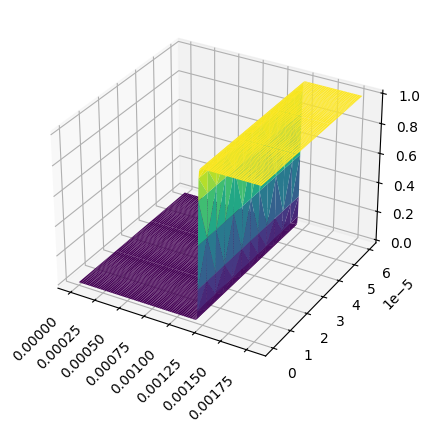

In [22]:
vertices = mesh.GetVertexArray()
ar = np.array(vertices)
x = psi # edit this line for what you want to plot

X = ar[:, 0]
Y = ar[:, 1]
# Z = ar[:, 2] 
Z = x.GetDataArray()

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(X, Y, Z, cmap='viridis')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()
